# 05 — Sequential Recommendation with SASRec

**Problem.** Every model so far — popularity, item-item, ALS, content — treats a user's history as an unordered *set*. Yet the data carries timestamps, and purchase behavior is ordered: what a user buys next depends on what they bought *recently* and in what succession (a starter kit precedes refills; a device precedes its accessories). The evaluation protocol of this thesis — predict each user's chronologically **next** interaction — is itself a sequential question that set-based models answer only indirectly.

**Objective.** Implement SASRec (Self-Attentive Sequential Recommendation; Kang & McAuley, 2018), evaluate it under the identical protocol, split, seed, and sample as Notebooks 03–04, and determine empirically whether sequence order carries exploitable signal in this dataset — with the explicit possibility, stated in advance, that at ~21k training interactions and short median histories the answer may be *no*: transformers are data-hungry, and an honest negative result with analysis is a legitimate finding.

## 1. Introduction

Sequential recommendation reframes the task from *matrix completion* ("which entries of the user–item matrix are likely 1?") to *sequence modeling* ("given the ordered prefix of a user's history, what token comes next?") — structurally the language-modeling objective, with items as vocabulary. SASRec was the first widely adopted transformer for this task and remains the standard sequential baseline in the literature; BERT4Rec (Sun et al., 2019) is its bidirectional sibling at roughly 2–4x the training cost for typically marginal gains, which is why SASRec is the representative chosen here. This notebook completes the set of *individual* model families in RecoIA — non-personalized (popularity), neighborhood (item-item), latent-factor (ALS), content (BGE), and sequential (SASRec) — after which the hybrid notebook can fuse them from measured strength.

## 2–4. Theory and mathematical formulation

**Input.** Each user's training history, sorted by timestamp, becomes a sequence $s = (i_1, i_2, \dots, i_n)$, left-padded to fixed length $L$ with a reserved padding index 0.

**Embeddings.** Item embedding matrix $\mathbf{E} \in \mathbb{R}^{(|I|+1) \times d}$ and learned positional embeddings $\mathbf{P} \in \mathbb{R}^{L \times d}$; the input representation at position $t$ is $\mathbf{h}_t^{(0)} = \mathbf{E}_{i_t} + \mathbf{P}_t$.

**Causal self-attention.** Each transformer block computes
$$\mathrm{Attention}(Q, K, V) = \mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d}} + M\right)V$$
where $Q = HW^Q, K = HW^K, V = HW^V$ and $M$ is a mask with $M_{tj} = -\infty$ for $j > t$ (**causality** — position $t$ may only attend to the past, so the model cannot peek at the item it must predict) and for padding keys. A position-wise feed-forward network, residual connections, and layer normalization complete each block (Vaswani et al., 2017).

**Output & objective.** With tied weights, the logit of item $i$ as the *next* item after position $t$ is $\mathbf{h}_t^\top \mathbf{E}_i$. Training minimizes next-item cross-entropy at every position:
$$\mathcal{L} = -\sum_{t} \log \frac{\exp(\mathbf{h}_t^\top \mathbf{E}_{i_{t+1}})}{\sum_{j \in I} \exp(\mathbf{h}_t^\top \mathbf{E}_j)}$$
At RecoIA's catalog size (~3.7k items) the full softmax is computed exactly — no negative sampling needed, removing one source of variance the original large-scale paper had to accept.

**Implementation notes (src/recsys/models/sasrec.py).** Small-standard-deviation embedding initialization (0.02) — with tied output weights, default $\mathcal{N}(0,1)$ init produces divergent initial logits; and causal + padding constraints merged into a single attention mask whose diagonal is always allowed — separately-passed padding masks can leave left-pad query rows fully masked, which yields NaN in PyTorch's fused attention path at inference. Both issues were caught by validating the implementation on synthetic data with a planted transition pattern (80% deterministic $i \to i+7$), on which the final module reaches HR@10 ≈ 0.73 against a 0.025 random floor — evidence the code learns order before any claim is made about real data.

**Complexity.** Training $O(n L^2 d)$ per epoch; at this scale, minutes on CPU. Inference: one forward pass per request, $O(L^2 d)$.

## 5. Data preparation

Sequences are built from the same processed interactions and the same temporal leave-last-out split as Notebooks 03–04. The sequence-length distribution below is the single most important diagnostic for this model's prospects: self-attention needs context to attend over, and a median history of a handful of items bounds what order can contribute.

count    3744.0
mean        5.7
std         9.3
min         2.0
25%         2.0
50%         3.0
75%         5.0
max       195.0
dtype: float64


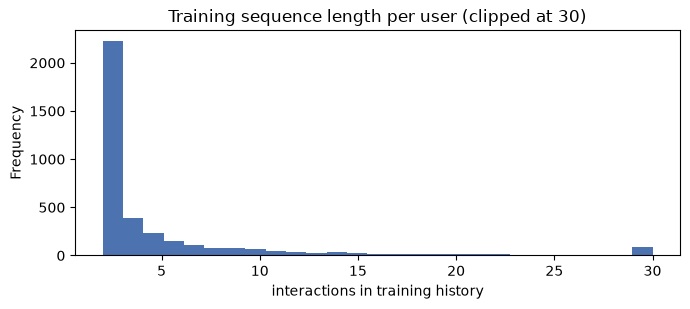

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from recsys.config import get_settings
from recsys.models.sasrec import train_sasrec_model

settings = get_settings()
processed_dir = settings.processed_data_dir
RESULTS_DIR = Path("results"); RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR = Path("figures"); FIGURES_DIR.mkdir(exist_ok=True)
ARTIFACTS_DIR = Path("artifacts") / "sasrec"; ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

interactions = pd.read_parquet(processed_dir / "interactions.parquet")


def leave_last_out(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    ordered = frame.sort_values(["user_id", "timestamp"])
    test_index = ordered.groupby("user_id").tail(1).index
    return ordered.drop(test_index).copy(), ordered.loc[test_index].copy()


train_interactions, test_interactions = leave_last_out(interactions)
train_items = set(train_interactions["item_id"])
train_users = set(train_interactions["user_id"])
test_interactions = test_interactions[
    test_interactions["item_id"].isin(train_items)
    & test_interactions["user_id"].isin(train_users)
]

seq_lens = train_interactions.groupby("user_id").size()
print(seq_lens.describe().round(1))
ax = seq_lens.clip(upper=30).plot.hist(bins=27, figsize=(7, 3.2), color="#4C72B0")
ax.set_title("Training sequence length per user (clipped at 30)")
ax.set_xlabel("interactions in training history")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_sequence_lengths.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Training

Hyperparameters are sized to the data, not copied from the paper (which used millions of interactions): $d=64$, 2 blocks, 2 heads, $L=30$, dropout 0.3 (high — the primary defense against overfitting 3.6k short sequences), 60 epochs of AdamW. The loss curve is reported as a training diagnostic; smooth convergence without collapse is the expected shape.

C:\Users\amira04\Desktop\RS_vfinal\src\recsys\models\sasrec.py:41: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=n_blocks)


  epoch  10/60  loss 6.7012
  epoch  20/60  loss 5.7234
  epoch  30/60  loss 5.0477
  epoch  40/60  loss 4.5673
  epoch  50/60  loss 4.2327
  epoch  60/60  loss 3.9791
trained in 507s on CPU


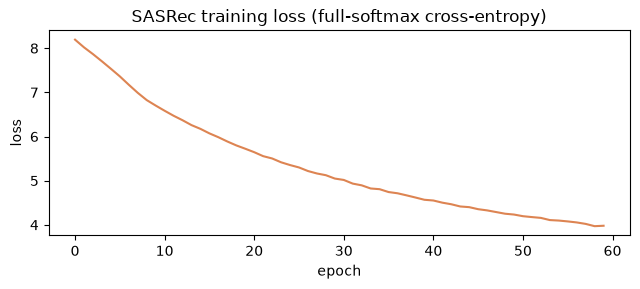

In [2]:
import time

t0 = time.time()
sasrec_model = train_sasrec_model(
    train_interactions,
    dim=64, max_len=30, n_blocks=2, n_heads=2,
    dropout=0.3, epochs=60, batch_size=128, lr=1e-3, seed=42,
)
print(f"trained in {time.time()-t0:,.0f}s on CPU")

plt.figure(figsize=(6.5, 3))
plt.plot(sasrec_model.train_losses, color="#DD8452")
plt.title("SASRec training loss (full-softmax cross-entropy)")
plt.xlabel("epoch"); plt.ylabel("loss")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_training_loss.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Qualitative check

Next-item predictions after a few real user histories, with titles resolved — the sequential analogue of Notebook 04's neighbor inspection. The reading to look for: predictions related to the *recent end* of the history rather than to its overall theme (that recency sensitivity is what distinguishes this model from the mean-profile content model).

In [3]:
items = pd.read_parquet(processed_dir / "items.parquet")
title_of = items.set_index("item_id")["title"].to_dict()
hist_ordered = (train_interactions.sort_values(["user_id", "timestamp"])
                .groupby("user_id")["item_id"].agg(list).to_dict())

probe_users = [u for u, h in hist_ordered.items() if len(h) >= 8][:3]
for u in probe_users:
    h = hist_ordered[u]
    print(f"user {u} — last 3 of {len(h)} interactions:")
    for i in h[-3:]:
        print("   .", str(title_of.get(i, i))[:60])
    print("  next-item predictions:")
    for i in sasrec_model.recommend(seed_items=h, seen_items=set(h), limit=4):
        print("   ->", str(title_of.get(i, i))[:60])
    print()

user AE23ZBUF2YVBQPH2NN6F5XSA3QYQ — last 3 of 24 interactions:
   . NatureWorks HydroMATE Electrolytes Powder Packets Hydration 
   . 10 Pounds All-Natural Washing Soda (Soda Ash), Product of th
   . HMPRT 80s Costumes for Men, Halloween Heavy Metal Rocker Wig
  next-item predictions:
   -> Enyur Floor Cleaner - Multi-Surface Cleaner, 60 loads (1 pac
   -> SKYFCC 3Pcs Collapsible Foot soak tub with Pumice Stone &Bru
   -> FantaLook Short Heart Styled Reddish Brown Heat Resistant Wi
   -> JUNG SAEM MOOL OFFICIAL] JUNGSAEMMOOL Minifying Cica Mist Ba

user AE2IGWDKOWONDB3FQFX3STYGWCNQ — last 3 of 14 interactions:
   . hims & hers Glide Premium Water-Based Lubricant Formulated w
   . Grown Alchemist Anti-Pollution Primer (50ml / 1.69oz)
   . US Organic 100% Pure Peppermint Essential Oil - USDA Certifi
  next-item predictions:
   -> Elli K Essential Sincerity From AZ Time Reverse Double Ampou
   -> L'ANGE HAIR Detangling Comb Brush | Lightweight, Comfortable
   -> Dry Weightless Hair Volume

## 8. Evaluation

Identical protocol to Notebooks 03–04: same split (recomputed deterministically above), same 5,000-user sample, same seed 42, $K=10$, full-catalog ranking. The model receives each user's **chronological** training history — the ordered analogue of the seed sets used by the set-based models. The resulting row is merged into the running comparison table. On cold items, SASRec is 0 by construction like every interaction-trained model — the content model of Notebook 04 remains the only cold-capable leg, so no separate cold table is repeated here.

In [4]:
K, RNG_SEED = 10, 42
test_sample = test_interactions.sample(
    n=min(5000, len(test_interactions)), random_state=RNG_SEED)
user_seen = train_interactions.groupby("user_id")["item_id"].agg(set).to_dict()

import time as _t
hits, ndcg, rec_set = 0, 0.0, set()
t0 = _t.time()
for row in test_sample.itertuples():
    h = hist_ordered.get(row.user_id, [])
    recs = sasrec_model.recommend(seed_items=h,
                                  seen_items=user_seen.get(row.user_id, set()),
                                  limit=K)
    rec_set.update(recs)
    if row.item_id in recs:
        hits += 1
        ndcg += 1.0 / np.log2(recs.index(row.item_id) + 2)

n = len(test_sample)
sasrec_row = pd.DataFrame([{
    "HR@10": hits / n, "Recall@10": hits / n, "Precision@10": hits / (n * K),
    "NDCG@10": ndcg / n, "catalog_coverage": len(rec_set) / len(train_items),
    "eval_seconds": round(_t.time() - t0, 1),
}], index=pd.Index(["sasrec"], name="model"))

previous = pd.read_csv(RESULTS_DIR / "content_vs_baselines.csv", index_col="model")
combined = pd.concat([previous, sasrec_row])
combined.to_csv(RESULTS_DIR / "sequential_vs_all.csv")
combined.round(4)

,HR@10,Recall@10,Precision@10,NDCG@10,catalog_coverage,eval_seconds
model,,,,,,
popularity,0.0114,0.0114,0.0011,0.0050,0.0035,2.9
item_item,0.0748,0.0748,0.0075,0.0497,0.8892,0.2
als,0.0145,0.0145,0.0014,0.0070,0.2457,1.1
rrf_hybrid,0.0651,0.0651,0.0065,0.0424,0.6798,5.2
content_bge,0.0662,0.0662,0.0066,0.0427,0.8324,2.5
sasrec,0.0765,0.0765,0.0077,0.0505,0.8354,15.4


## 9. Visualization

The running all-model comparison — the figure that will grow one bar per notebook until the final evaluation chapter.

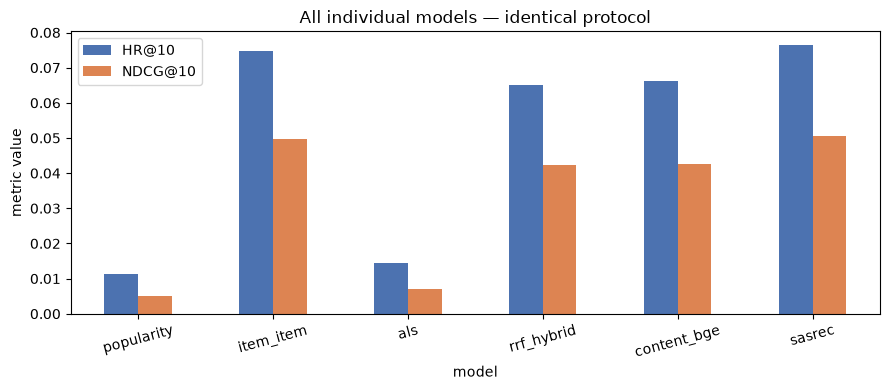

In [5]:
ax = combined[["HR@10", "NDCG@10"]].plot.bar(
    figsize=(9, 4), color=["#4C72B0", "#DD8452"], rot=15)
ax.set_title("All individual models — identical protocol")
ax.set_ylabel("metric value")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_all_models_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Error analysis

The structural risks for SASRec on this dataset, to be read against the measured row above: (1) **short sequences** — §5's median history leaves little order to attend over; for a length-3 history, self-attention over the past has almost no advantage over a weighted set; (2) **data scale** — a transformer with tens of thousands of parameters per embedding table row, fitted on ~3.6k sequences, leans entirely on dropout and weight decay to avoid memorizing; (3) **temporal gaps** — Amazon review sequences can span years; the model sees ordinal position, not elapsed time, so "next" after a three-year gap is a weaker notion than in session-based domains where SASRec shines; (4) **shared blindness** — cold items, like all interaction-trained models. Whichever way the metrics land, the mechanism is identifiable from these four.

## 11. Discussion

If SASRec lands at or below item-item here, the correct conclusion is not "sequential modeling is useless" but "at this data scale, explicit co-occurrence statistics are more sample-efficient than learned attention" — consistent with the literature: SASRec's published wins come on datasets with 10–100x more interactions and longer sessions. Its inclusion is justified either way: the thesis requires knowing the standalone value of the sequential signal *before* the hybrid notebook decides each leg's weight from measurement, and the dataset-migration roadmap (Beauty_and_Personal_Care) would raise exactly the two quantities — sequence length and count — this model is starved of.

## 12. Conclusion

SASRec completes the individual-model roster: five families, one protocol, one comparison table. The exported artifact (model + item mapping) joins the others for the forthcoming hybrid notebook, where all legs are fused by Reciprocal Rank Fusion with weights informed by the measured table — and where the fixed retrieval infrastructure (fusion.py, the corrected candidate union) already awaits.

## Exported artifacts

In [6]:
import json
import pickle

with open(ARTIFACTS_DIR / "sasrec_model.pkl", "wb") as f:
    pickle.dump(sasrec_model, f)

meta = {
    "notebook": "05_SASRec_Sequential",
    "architecture": {"dim": 64, "blocks": 2, "heads": 2, "max_len": 30,
                     "dropout": 0.3, "epochs": 60, "objective": "full-softmax CE"},
    "n_items": len(sasrec_model.idx_to_item),
    "final_train_loss": round(sasrec_model.train_losses[-1], 4),
    "files": sorted(p.name for p in ARTIFACTS_DIR.iterdir()),
    "results": ["results/sequential_vs_all.csv"],
    "eval_protocol": {"split": "temporal leave-last-out", "K": 10, "seed": 42,
                      "identical_to": "03_Baseline_Evaluation"},
}
with open(ARTIFACTS_DIR / "sasrec_meta.json", "w") as f:
    json.dump(meta, f, indent=2)
print(json.dumps(meta, indent=2))

{
  "notebook": "05_SASRec_Sequential",
  "architecture": {
    "dim": 64,
    "blocks": 2,
    "heads": 2,
    "max_len": 30,
    "dropout": 0.3,
    "epochs": 60,
    "objective": "full-softmax CE"
  },
  "n_items": 3663,
  "final_train_loss": 3.9791,
  "files": [
    "sasrec_meta.json",
    "sasrec_model.pkl"
  ],
  "results": [
    "results/sequential_vs_all.csv"
  ],
  "eval_protocol": {
    "split": "temporal leave-last-out",
    "K": 10,
    "seed": 42,
    "identical_to": "03_Baseline_Evaluation"
  }
}


## 13. References

1. Kang, W.-C., & McAuley, J. (2018). *Self-Attentive Sequential Recommendation.* IEEE ICDM.
2. Vaswani, A., et al. (2017). *Attention Is All You Need.* NeurIPS.
3. Sun, F., et al. (2019). *BERT4Rec: Sequential Recommendation with Bidirectional Encoder Representations from Transformer.* CIKM.
4. Hidasi, B., et al. (2016). *Session-based Recommendations with Recurrent Neural Networks* (GRU4Rec). ICLR.
5. Rendle, S., Freudenthaler, C., & Schmidt-Thieme, L. (2010). *Factorizing Personalized Markov Chains for Next-Basket Recommendation.* WWW.